In [1]:
import pandas as pd
import sqlite3
from pathlib import Path

conn = sqlite3.connect(Path("../data/finance.db"))

def q(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or {})

In [2]:
monthly = q("""
SELECT 
    substr(transaction_date, 1, 7) AS month,
    ROUND(SUM(CASE WHEN amount <> 0 THEN amount ELSE 0 END), 2) AS total_spend
FROM transactions
WHERE category_id IN (SELECT category_id FROM categories WHERE category_name IS NOT "Income")
GROUP BY 1
ORDER BY 1;
""")
monthly

,month,total_spend
0,2025-11,-3982.19
1,2025-12,-2225.24
2,2026-01,-677.33


In [3]:
cat_mix = q("""
SELECT
    c.category_name,
    ROUND(SUM(CASE WHEN t.amount <> 0 THEN amount ELSE 0 END), 2) AS spend
FROM transactions t
JOIN categories c ON c.category_id = t.category_id
GROUP BY 1
ORDER BY spend DESC;
""")
cat_mix.head(15)

,category_name,spend
0,Income,10173.38
1,Transfers,244.75
2,Entertainment,-44.18
3,Food,-59.05
4,Coffee,-70.43
5,Transport,-159.85
6,Uncategorized,-200.83
7,Gas,-277.55
8,Retail,-348.55
9,Bills,-400.67


In [ ]:
top_merchants = q("""
SELECT
    m.merchant_name,
    ROUND(SUM(CASE WHEN t.amount <> 0 THEN amount ELSE 0 END), 2) AS spend
FROM transactions t
JOIN merchants m ON (CASE WHEN m.merchant_name <> "Income" THEN m.merchant_id = t.merchant_id ELSE 0 END)
GROUP BY 1
HAVING spend < 0
ORDER BY spend DESC
LIMIT 15;
""")
top_merchants

,merchant_name,spend
0,Transfers,244.75
1,Interest,4.46


In [5]:
rolling = q("""
WITH monthly AS (
    SELECT 
        substr(transaction_date,1,7) AS month,
        SUM(CASE WHEN amount <> 0 THEN amount ELSE 0 END) AS spend
    FROM transactions
    GROUP BY 1
)
SELECT
    month,
    ROUND(spend,2) AS spend,
    ROUND(AVG(spend) OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS rolling_3mo_avg
FROM monthly
ORDER BY month;
""")
rolling

,month,spend,rolling_3mo_avg
0,2025-11,3874.62,3874.62
1,2025-12,91.33,1982.97
2,2026-01,-677.33,1096.21


In [6]:
monthly_income_spend = q("""
SELECT
  substr(transaction_date, 1, 7) AS month,
  ROUND(SUM(CASE WHEN amount > 0 THEN amount ELSE 0 END), 2) AS total_income,
  ROUND(SUM(CASE WHEN amount < 0 THEN -amount ELSE 0 END), 2) AS total_spend,
  ((ROUND(SUM(CASE WHEN amount > 0 THEN amount ELSE 0 END), 2)) - (ROUND(SUM(CASE WHEN amount < 0 THEN -amount ELSE 0 END), 2))) AS Net_Remainder
FROM transactions
GROUP BY 1
ORDER BY 1;
""")

monthly_income_spend

,month,total_income,total_spend,Net_Remainder
0,2025-11,7856.81,3982.19,3874.62
1,2025-12,2714.81,2623.48,91.33
2,2026-01,0.00,677.33,-677.33


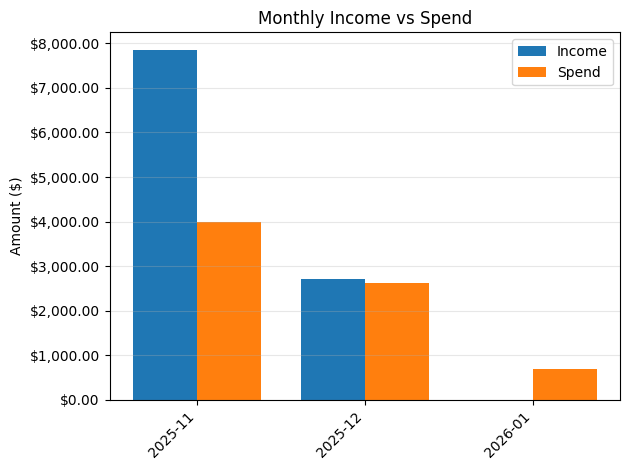

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np

plot_df = monthly_income_spend.copy()

x = np.arange(len(plot_df["month"])) 
width = 0.38

plt.figure()
plt.bar(x - width/2, plot_df["total_income"], width=width, label="Income")
plt.bar(x + width/2, plot_df["total_spend"], width=width, label="Spend")

plt.xticks(x, plot_df["month"], rotation=45, ha="right")
plt.ylabel("Amount ($)")
plt.title("Monthly Income vs Spend")
plt.grid(True, axis="y", alpha=0.3)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))
plt.legend()
plt.tight_layout()
plt.show()